In [1]:
### PRELUDE
import numpy as np
import sys
import matplotlib.pyplot as plt
from pathlib import Path

# Enable autoreload
%load_ext autoreload
%autoreload 2

# Add workspace to sys.path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
###

from seemps.analysis.mesh import RegularInterval
from seemps.analysis.expansion.expansion import PolynomialExpansion
from seemps.analysis.expansion import ChebyshevExpansion, GegenbauerExpansion, mps_polynomial_expansion

Text(0.5, 1.0, 'Heaviside step')

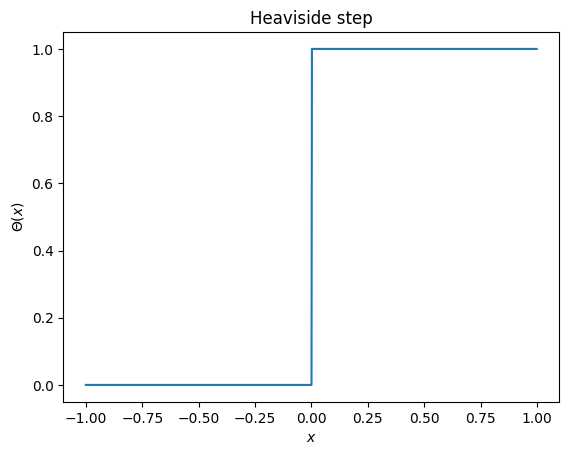

In [2]:
a, b = -1.0, 1.0
n = 10
N = 2**n
x = RegularInterval(a, b, N)
x_exact = x.to_vector()

fn = lambda x: (x > 0).astype(float)
y_exact = fn(x_exact)

plt.plot(x_exact, y_exact)
plt.xlabel(r"$x$")
plt.ylabel(r"$\Theta(x)$")
plt.title("Heaviside step")

Text(0.5, 1.0, 'Chebyshev expansion')

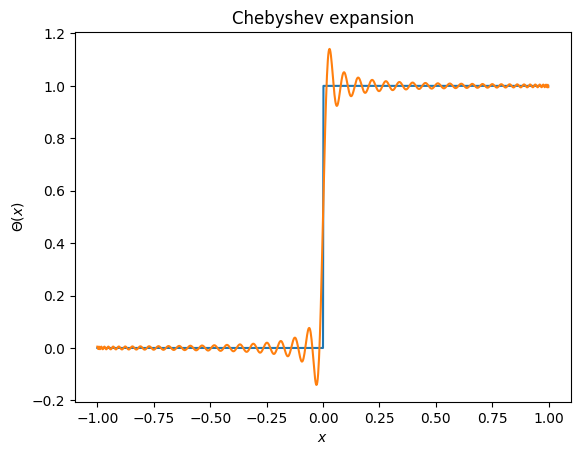

In [3]:
cheb_expansion = ChebyshevExpansion.project(fn, a, b, 100)
mps_cheb = mps_polynomial_expansion(cheb_expansion, x)

y_cheb = mps_cheb.to_vector()
plt.plot(x_exact, y_exact)
plt.plot(x_exact, y_cheb)
plt.xlabel(r"$x$")
plt.ylabel(r"$\Theta(x)$")
plt.title("Chebyshev expansion")

In [4]:
def gegenbauer_filter(
        expansion: PolynomialExpansion, 
        order: int | None = None, 
        α: int | None = None
    ) -> GegenbauerExpansion:
    pass

In [5]:
geg_expansion = gegenbauer_filter(cheb_expansion, α=1.5)
mps_geg = mps_polynomial_expansion(geg_expansion, x)

y_geg = mps_geg.to_vector()
plt.plot(x_exact, y_exact)
plt.plot(x_exact, y_geg)
plt.xlabel(r"$x$")
plt.ylabel(r"$\Theta(x)$")
plt.title("Gegenbauer expansion")

AttributeError: 'NoneType' object has no attribute 'domain'